RGB A HSV

C:\Users\USER\AppData\Local\Temp\ipykernel_36056\874918634.py:34: RuntimeWarning: invalid value encountered in scalar divide
  new_img[i,j,0]= 60*((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))


Text(0.5, 1.0, 'canal value')

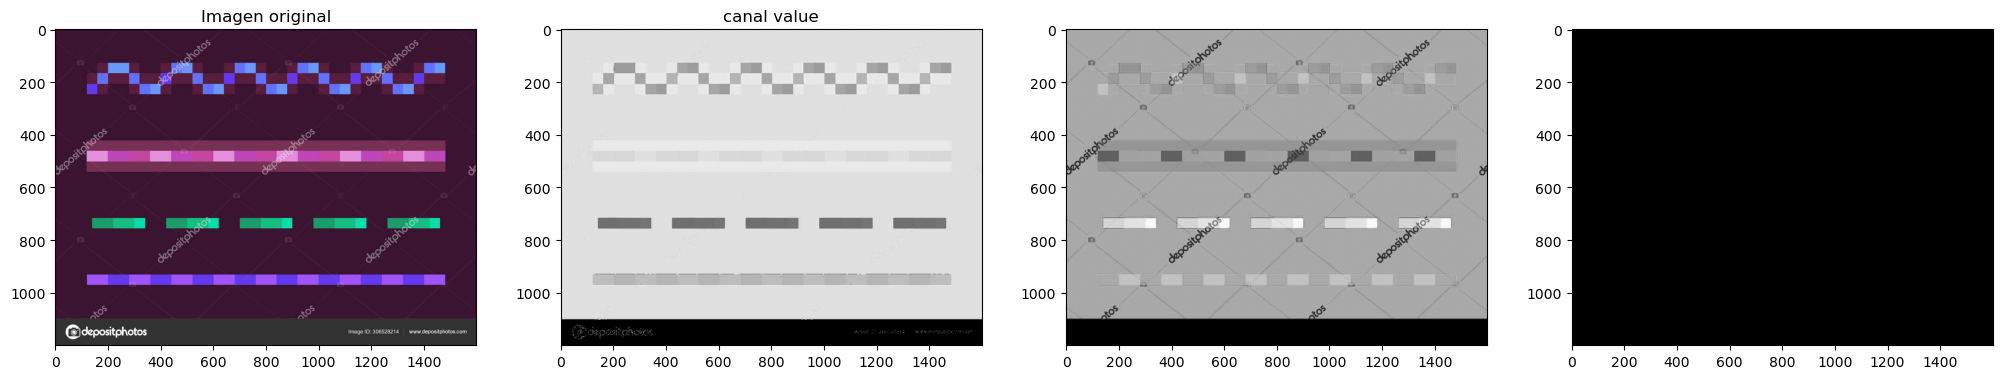

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Imagen1 = cv2.imread("imagen.jpg")
img=cv2.cvtColor(Imagen1, cv2.COLOR_BGR2RGB)
def RGB2HSV(img):
    img=img.astype(np.float32)
    img=img/255
    new_img=np.zeros_like(img)

    maxChanel=np.argmax(img,axis=2)
    maxValue=np.amax(img,axis=2)
    minChanel=np.argmin(img,axis=2)
    minValue=np.amin(img,axis=2)
    #calculo de value
    new_img[...,2]=maxValue

    #calculo de saturacion

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1]==0
            elif maxValue[i,j] !=0:
                new_img[i,j,1]=(new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #calculo de hue
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3==img[i,j,0]:
                new_img[i,j,0]=0
            elif maxChanel[i,j]==0:#R
                new_img[i,j,0]= 60*((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChanel[i,j]==1:#G
                new_img[i,j,0]= 120+60*((img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChanel[i,j]==2:#B
                new_img[i,j,0]= 240+60*((img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j]))
        img2=new_img[...,0]<0
        new_img[img2,0]=new_img[img2,0]+360
    return new_img

hsv_img=RGB2HSV(img)
fig,axs=plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('Imagen original')
fig_img=axs[1].imshow(hsv_img[...,0],cmap='gray',vmin=0,vmax=360)
axs[1].set_title('canal hue')
fig_img=axs[2].imshow(hsv_img[...,1],cmap='gray',vmin=0,vmax=1)
axs[1].set_title('canal saturacion')
fig_img=axs[3].imshow(hsv_img[...,2],cmap='gray',vmin=0,vmax=360)
axs[1].set_title('canal value')

Text(0.5, 1.0, 'canal value')

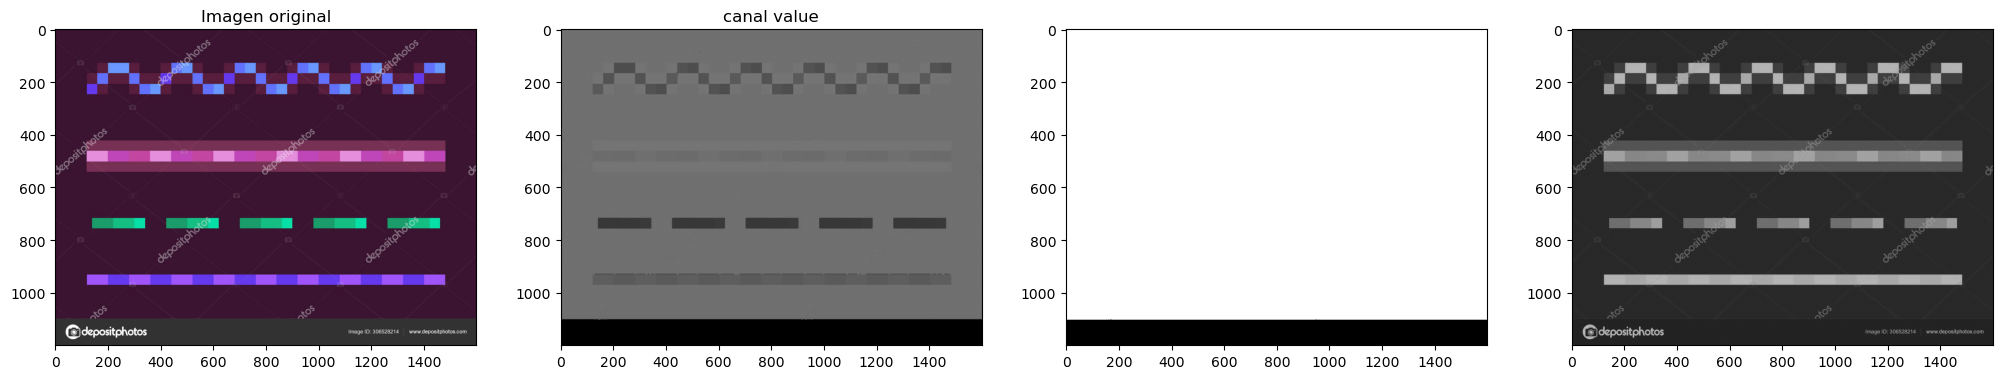

In [4]:
hsv_img_cv2=cv2.cvtColor(img,cv2.COLOR_RGB2HSV)
fig,axs=plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('Imagen original')
fig_img=axs[1].imshow(hsv_img_cv2[...,0],cmap='gray',vmin=0,vmax=360)
axs[1].set_title('canal hue')
fig_img=axs[2].imshow(hsv_img_cv2[...,1],cmap='gray',vmin=0,vmax=1)
axs[1].set_title('canal saturacion')
fig_img=axs[3].imshow(hsv_img_cv2[...,2],cmap='gray',vmin=0,vmax=360)
axs[1].set_title('canal value')

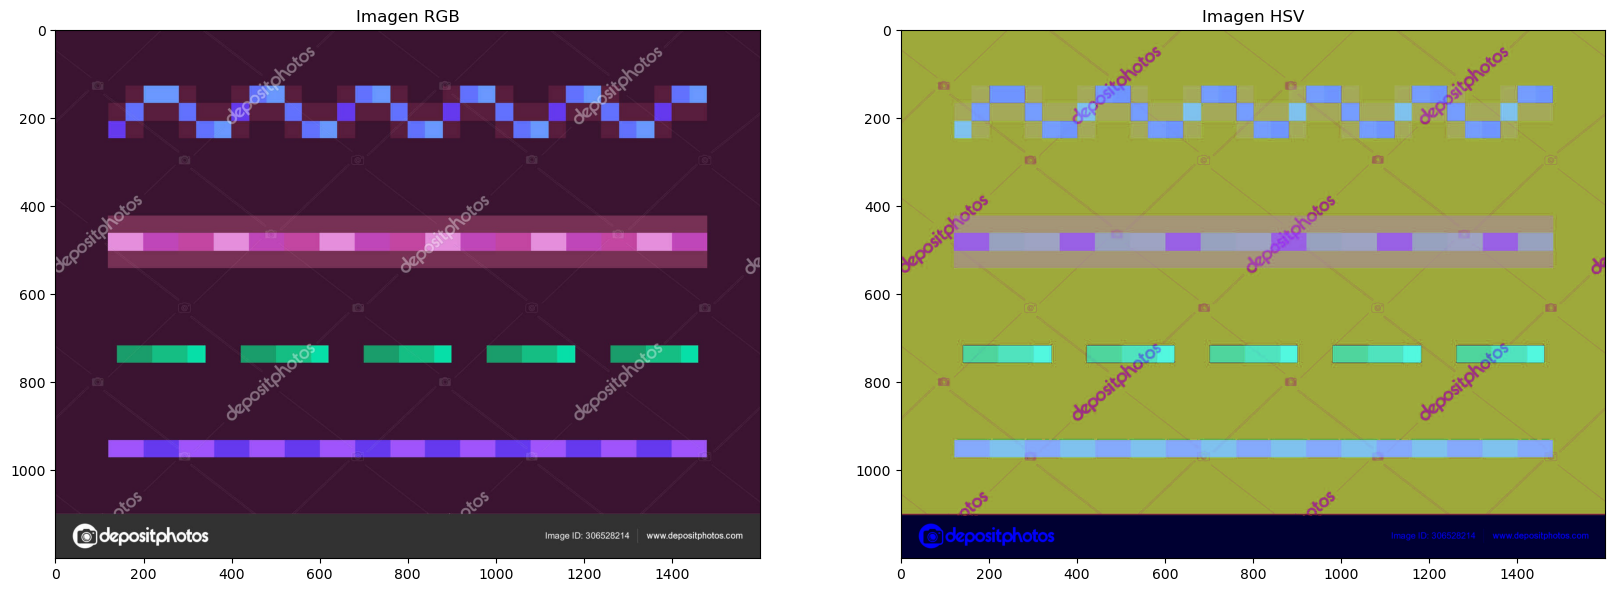

Imagen HSV guardada como 'imagentres.jpg'


In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_rbg=cv2.cvtColor(cv2.imread('imagen.jpg',cv2.IMREAD_COLOR),cv2.COLOR_BGR2RGB)
img_hsv=cv2.cvtColor(img_rbg,cv2.COLOR_RGB2HSV)

fig,axs=plt.subplots(1,2,figsize=(20,10))
axs[0].imshow(img_rbg)
axs[0].set_title('Imagen RGB')
axs[1].imshow(img_hsv)
axs[1].set_title('Imagen HSV')
plt.show()

# Guardar la imagen HSV directamente (sin convertir)
cv2.imwrite('imagentres.jpg', img_hsv)
print("Imagen HSV guardada como 'imagentres.jpg'")